<a href="https://colab.research.google.com/github/eojin22/ESAA/blob/main/OB_WEEK03_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **추천 시스템**

## **추천 시스템의 개요와 배경**
### 온라인 스토어의 필수요소, 추천 시스템
구성
- 사용자가 어떤 상품을 구매했는가?
- 사용자가 어떤 상품을 둘러보거나 장바구니에 넣었는가?
- 사용자가 평가한 영화 평점은? 제품 평가는?
- 사용자가 스스로 작성한 자신의 취향은?
- 사용자가 무엇을 클릭했는가?


### 추천 시스템의 유형
- 콘텐츠 기반 필터링(Content based filtering)
- 협업 필터링(Collaborative Filtering)
  - 최근접 이웃(Nearest Neighbor) 협업 필터링
  - 잠재 요인(Latent Factor) 협업 필터링

## **콘텐츠 기반 필터링 추천 시스템**
- 사용자가 특정한 아이템을 매우 선호하는 경우, 그 아이템과 비슷한 콘텐츠를 가진 다른 아이템을 추천하는 방식

## **최근접 이웃 협업 필터링**
**협업 필터링**
- 사용자가 아이템에 매긴 평점 정보나 상품 구매 이력과 같은 사용자 행동 양식만을 기반으로 추천을 수행하는 것
- 목표: 사용자-아이템 평점 매트릭스와 같은 축적된 사용자 행동 데이터를 기반으로 사용자가 아직 평가하지 않은 아이템을 예측 평가하는 것
- 최근접 이웃 방식, 잠재 요인 방식 모두 사용자-아이템 평점 행렬 데이터에만 의지해 추천 수행
- 희소 행렬 특성을 가짐

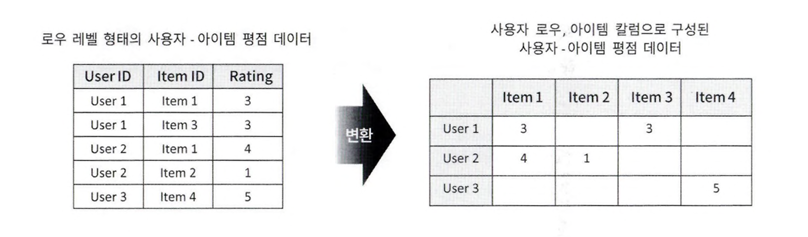

## **잠재 요인 협업 필터링**
: 사용자-아이템 평점 매트릭스 속에 숨어 있는 잠재 요인을 추출해 추천 예측을 할 수 있게 하는 기법

- 행렬 분해(Matrix Factorization): 대규모 다차원 행렬을 SVD와 같은 차원 감소 기법으로 분해하는 과정에서 잠재 요인 추출
- 사용자-아이템 평점 행렬 데이터만을 이용해 잠재 요인을 끄집어 내는 것
- 잠재 요인을 기반으로 다차원 희소 행렬인 사용자-아이템 행렬 데이터를 저차원 밀집 행렬의 사용자-잠재 요인 행렬과 아이템-잠재 요인 행렬의 전치 행렬로 분해 가능

### 행렬 분해의 이해
- 다차원의 매트릭스를 저차원 매트릭스로 분해하는 기법 (SVD, NMF 등)
  - SVD는 NaN 값이 없는 행렬에만 적용 가능
  - 확률적 경사 하강법(SGD)이나 ALS(Alternating Least Squares) 방식을 이용해 SVD 수행

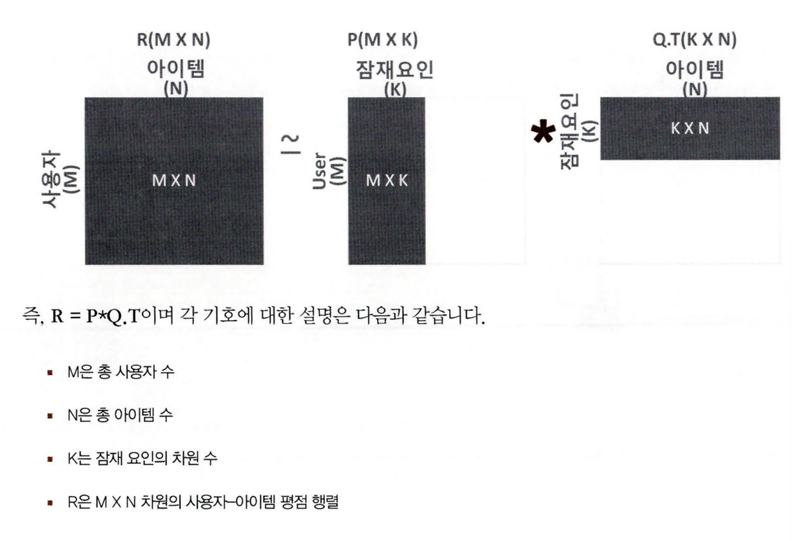

### 확률적 경사 하강법을 이용한 행렬 분해
- P와 Q 행렬로 계산된 예측 R 행렬 값이 실제 R 행렬 값과 가장 최소의 오류를 가질 수 있도록 반복적인 비용 함수 최적화를 통해 P와 Q를 유추해내는 것


In [1]:
import numpy as np

# 원본 행렬 R 생성, 분해 행렬 P와 Q 초기화, 잠재 요인 차원 K는 3으로 설정.
R = np.array([[4, np.nan, np.nan, 2, np.nan],
              [np.nan, 5, np.nan, 3, 1],
              [np.nan, np.nan, 3, 4, 4],
              [5, 2, 1, 2, np.nan]])

num_users, num_items = R.shape
K = 3

# P와 Q 행렬의 크기를 지정하고 정규 분포를 가진 임의의 값으로 입력합니다.
np.random.seed(1)

P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_items, K))

In [2]:
from sklearn.metrics import mean_squared_error

def get_rmse(R, P, Q, non_zeros):
    error = 0

    # 두 개의 분해된 행렬 P와 Q.T의 내적으로 예측 R 행렬 생성
    full_pred_matrix = np.dot(P, Q.T)

    # 실제 R 행렬에서 널이 아닌 값의 위치 인덱스 추출해
    # 실제 R 행렬과 예측 행렬의 RMSE 추출
    x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
    y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]

    R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
    full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]

    mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse = np.sqrt(mse)

    return rmse

- SGD 기반으로 행렬 분해 수행
- R에서 널 값을 제외한 데이터의 행렬 인덱스 추출
  - steps: SGD를 반복해서 업데이트할 횟수
  - learning_rate: SGD의 학습률
  - r_lambda: L2 Regularization 계수
  - get_rmse() 함수를 통해 50회 반복할 때마다 오류 값 출력

In [3]:
# R > 0인 행 위치, 열 위치, 값을 non_zeros 리스트에 저장.
non_zeros = [(i, j, R[i, j])
             for i in range(num_users)
             for j in range(num_items)
             if R[i, j] > 0]

steps = 1000
learning_rate = 0.01
r_lambda = 0.01

# SGD 기법으로 P와 Q 매트릭스를 계속 업데이트.
for step in range(steps):
    for i, j, r in non_zeros:

        # 실제 값과 예측 값의 차이인 오류 값 구함
        eij = r - np.dot(P[i, :], Q[j, :].T)

        # Regularization을 반영한 SGD 업데이트 공식 적용
        P[i, :] = P[i, :] + learning_rate * (
            eij * Q[j, :] - r_lambda * P[i, :]
        )

        Q[j, :] = Q[j, :] + learning_rate * (
            eij * P[i, :] - r_lambda * Q[j, :]
        )

    rmse = get_rmse(R, P, Q, non_zeros)

    if step % 50 == 0:
        print("### iteration step : ", step, " rmse : ", rmse)

### iteration step :  0  rmse :  3.2388050277987723
### iteration step :  50  rmse :  0.4876723101369648
### iteration step :  100  rmse :  0.1564340384819247
### iteration step :  150  rmse :  0.07455141311978046
### iteration step :  200  rmse :  0.04325226798579314
### iteration step :  250  rmse :  0.029248328780878973
### iteration step :  300  rmse :  0.022621116143829466
### iteration step :  350  rmse :  0.019493636196525135
### iteration step :  400  rmse :  0.018022719092132704
### iteration step :  450  rmse :  0.01731968595344266
### iteration step :  500  rmse :  0.016973657887570753
### iteration step :  550  rmse :  0.016796804595895633
### iteration step :  600  rmse :  0.01670132290188466
### iteration step :  650  rmse :  0.01664473691247669
### iteration step :  700  rmse :  0.016605910068210026
### iteration step :  750  rmse :  0.016574200475705
### iteration step :  800  rmse :  0.01654431582921597
### iteration step :  850  rmse :  0.01651375177473524
### iterati

- 분해된 P와 Q 함수를 P*Q.T로 예측 행렬을 만들어서 출력

In [4]:
pred_matrix = np.dot(P, Q.T)

print('예측 행렬:\n', np.round(pred_matrix, 3))

예측 행렬:
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]
